In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import numpy as np
import os

/opt/anaconda3/envs/timedrl/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Create OOD datasets

In [39]:
def filter_and_save(split_name, base_path="../dataset/classification/PenDigits/"):
    # Load the original data
    load_path = os.path.join(base_path, f"{split_name}_orig.pt")
    data = torch.load(load_path)
    
    samples = data["samples"]
    labels = data["labels"]

    # Create mask: keep everything EXCEPT labels 1 and 4
    # mask = (labels != 1) & (labels != 4)

    # Create mask: Keep ONLY labels 1 and 4 (the OOD classes)
    mask = (labels == 1) | (labels == 4)

    filtered_dataset = {
        "samples": samples[mask],
        "labels": labels[mask]
    }

    # Save the filtered version
    save_path = os.path.join(base_path, f"{split_name}.pt")
    torch.save(filtered_dataset, save_path)
    
    print(f"Processed {split_name}: {len(samples)} -> {len(filtered_dataset['samples'])} samples.")



splits = ["train", "test", "val"]
for s in splits:
    filter_and_save(s)

Processed train: 7494 -> 1559 samples.
Processed test: 3498 -> 728 samples.


In [4]:
dataset = torch.load("../dataset/classification/HAR_orig/test_ood.pt")

In [5]:
labels = dataset.get("labels").numpy()

unique, counts = np.unique(labels, return_counts=True)

In [6]:
print(dict(zip(unique, counts)))

{1.0: 471, 4.0: 532}


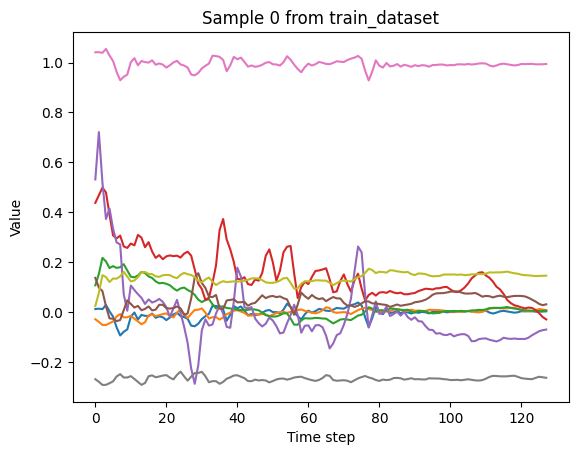

In [7]:
sample = dataset.get('samples')[0]

plt.figure()
plt.plot(sample)
plt.xlabel("Time step")
plt.ylabel("Value")
plt.title("Sample 0 from train_dataset")
plt.show()

# Distort data to be more OOD-like

In [7]:
path = "../dataset/classification/Har_orig/"

train_data = torch.load(os.path.join(path, "train_ood.pt"))
val_data = torch.load(os.path.join(path, "val_ood.pt"))
test_data = torch.load(os.path.join(path, "test_ood.pt"))

In [8]:
def apply_ood_distortions(data_tensor, intensity=1.0, attenuation_prob=0.3):
    x = data_tensor.clone().float()
    n_batches, seq_len, n_channels = x.shape
    device = x.device
    
    # 1. Per-Channel Gaussian Jittering
    # Adds high-frequency noise across all channels
    noise = torch.randn_like(x) * 0.2 * intensity
    x = x + noise

    # 2. Independent Channel Scaling (The 'Dynamic Range' Shift)
    # Each channel gets a unique, large scaling factor to break inter-channel relationships
    scales = torch.empty(n_channels).uniform_(1.5, 3.5).to(device) * intensity
    x = x * scales.view(1, 1, -1)

    # 3. Full Channel Permutation (The 'Chaos' Swap)
    # Randomly shuffles the identity of every channel
    perm = torch.randperm(n_channels)
    x = x[:, :, perm]

    # 4. Signal Attenuation (Instead of Dropout)
    # Instead of zeroing out, we reduce the signal to 5% of its original magnitude
    # This keeps the 'shape' but makes the features statistically 'weird'
    attenuation_mask = torch.rand(n_channels).to(device)
    
    # For channels where the random value < attenuation_prob, we multiply by a tiny factor
    # For others, we multiply by 1.0 (keep)
    multipliers = torch.where(attenuation_mask < attenuation_prob, 0.05, 1.0)
    
    # Force at least one channel to be attenuated if none were picked
    if (multipliers == 1.0).all():
        multipliers[np.random.randint(0, n_channels)] = 0.05

    x = x * multipliers.view(1, 1, -1)

    return x

In [10]:
# --- Execution ---
path = "../dataset/classification/WISDM_distort/"
files = ["train_ood.pt", "val_ood.pt", "test_ood.pt"]

for file in files:
    full_path = os.path.join(path, file)
    if os.path.exists(full_path):
        print(f"Distorting {file}...")
        
        # Load the dictionary (assuming standard HAR .pt format)
        data_dict = torch.load(full_path)
        
        # Distort the samples
        # Assuming the key is 'samples' or 'data'
        key = 'samples' if 'samples' in data_dict else 'data'
        data_dict[key] = apply_ood_distortions(data_dict[key])
        
        # Save back
        torch.save(data_dict, full_path)

print("Done! Your dataset is now officially 'distorted' and ready for OOD testing.")

Distorting train_ood.pt...
Distorting val_ood.pt...
Distorting test_ood.pt...
Done! Your dataset is now officially 'distorted' and ready for OOD testing.


In [ ]:
sample = torch.load("../dataset/classification/WISDM_distort/test_ood.pt").get('samples')[0]
sample = apply_ood_distortions(sample.unsqueeze(0)).squeeze(0)  # Distort the sample for visualization

plt.figure()
plt.plot(sample)
plt.xlabel("Time step")
plt.ylabel("Value")
plt.title("Sample 0 from train_dataset")
plt.show()

In [23]:
import os
import torch
import numpy as np

# --- Distortion function (unchanged, but parameterized) ---
def apply_ood_distortions(data_tensor, intensity=1.0, attenuation_prob=0.3):
    x = data_tensor.clone().float()
    n_batches, seq_len, n_channels = x.shape
    device = x.device
    
    # 1. Gaussian noise
    noise = torch.randn_like(x) * 0.2 * intensity
    x = x + noise

    # 2. Channel scaling
    scales = torch.empty(n_channels).uniform_(1.5, 3.5).to(device) * intensity
    x = x * scales.view(1, 1, -1)

    # 3. Channel permutation
    perm = torch.randperm(n_channels)
    x = x[:, :, perm]

    # 4. Signal attenuation
    attenuation_mask = torch.rand(n_channels).to(device)
    multipliers = torch.where(attenuation_mask < attenuation_prob, 0.05, 1.0)

    if (multipliers == 1.0).all():
        multipliers[np.random.randint(0, n_channels)] = 0.05

    x = x * multipliers.view(1, 1, -1)

    return x


# --- Paths ---
src_path = "../dataset/classification/WISDM_orig/"
files = ["train_ood.pt", "val_ood.pt", "test_ood.pt"]

# --- Distortion levels ---
distortion_levels = [
    {"name": "WISDM_distorted1", "intensity": 0.5, "attenuation_prob": 0.2},
    {"name": "WISDM_distorted2", "intensity": 1.0, "attenuation_prob": 0.3},
    {"name": "WISDM_distorted3", "intensity": 1.5, "attenuation_prob": 0.4},
    {"name": "WISDM_distorted4", "intensity": 2.0, "attenuation_prob": 0.5},
]

# --- Main loop ---
for level in distortion_levels:
    dst_path = f"../dataset/classification/{level['name']}/"
    os.makedirs(dst_path, exist_ok=True)

    print(f"\nCreating {level['name']}...")

    for file in files:
        src_file = os.path.join(src_path, file)
        dst_file = os.path.join(dst_path, file)

        if os.path.exists(src_file):
            data_dict = torch.load(src_file)

            key = 'samples' if 'samples' in data_dict else 'data'

            data_dict[key] = apply_ood_distortions(
                data_dict[key],
                intensity=level["intensity"],
                attenuation_prob=level["attenation_prob"] if "attenation_prob" in level else level["attenuation_prob"]
            )

            torch.save(data_dict, dst_file)

            print(f"Saved {dst_file}")

print("\nDone! 4 levels of OOD datasets generated.")


Creating WISDM_distorted1...
Saved ../dataset/classification/WISDM_distorted1/train_ood.pt
Saved ../dataset/classification/WISDM_distorted1/val_ood.pt
Saved ../dataset/classification/WISDM_distorted1/test_ood.pt

Creating WISDM_distorted2...
Saved ../dataset/classification/WISDM_distorted2/train_ood.pt
Saved ../dataset/classification/WISDM_distorted2/val_ood.pt
Saved ../dataset/classification/WISDM_distorted2/test_ood.pt

Creating WISDM_distorted3...
Saved ../dataset/classification/WISDM_distorted3/train_ood.pt
Saved ../dataset/classification/WISDM_distorted3/val_ood.pt
Saved ../dataset/classification/WISDM_distorted3/test_ood.pt

Creating WISDM_distorted4...
Saved ../dataset/classification/WISDM_distorted4/train_ood.pt
Saved ../dataset/classification/WISDM_distorted4/val_ood.pt
Saved ../dataset/classification/WISDM_distorted4/test_ood.pt

Done! 4 levels of OOD datasets generated.


Skipping HAR_orig: File not found at ../dataset/classification/HAR_orig/test.pt


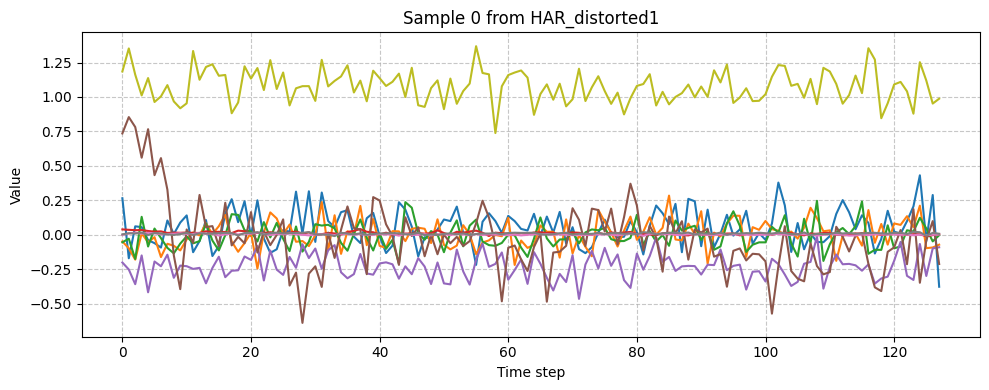

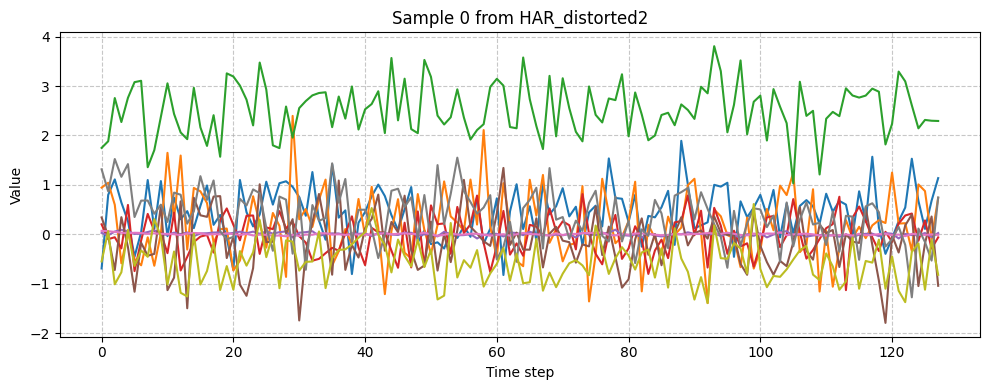

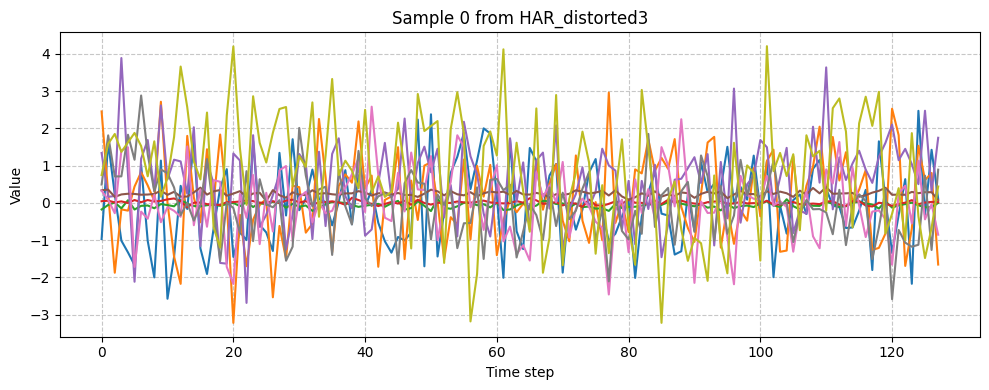

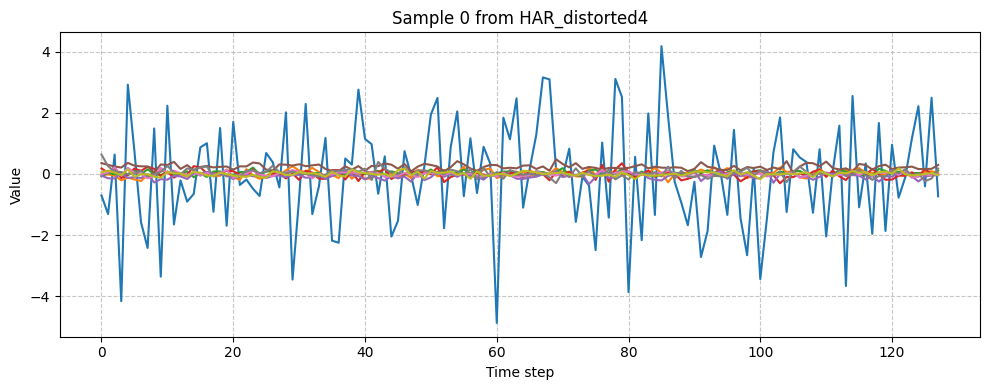

In [3]:
import torch
import matplotlib.pyplot as plt
import os

# Define the folder names
folders = ['HAR_distorted1', 'HAR_distorted2', 'HAR_distorted3', 'HAR_distorted4']
base_path = "../dataset/classification/"

# Iterate through each folder to create individual plots
for folder in folders:
    # Construct the full path to the .pt file
    file_path = os.path.join(base_path, folder, "test.pt")
    
    try:
        # Load the dataset dictionary
        dataset = torch.load(file_path)
        
        # Extract the first sample (index 0) from the 'samples' key
        sample = dataset.get('samples')[0]
        
        # Convert to numpy for plotting if it's a torch tensor
        if torch.is_tensor(sample):
            sample_data = sample.detach().cpu().numpy()
        else:
            sample_data = sample

        # Create the figure
        plt.figure(figsize=(10, 4))
        plt.plot(sample_data)
        plt.xlabel("Time step")
        plt.ylabel("Value")
        plt.title(f"Sample 0 from {folder}")
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
        
    except FileNotFoundError:
        print(f"Skipping {folder}: File not found at {file_path}")
    except Exception as e:
        print(f"An error occurred while processing {folder}: {e}")